# Preparing data for each participant

##  Objectives
- To prepare the data for each participant in one big table.
- To preprocess data to make it ready for ML pipeline

From data exploration, we found there are several useful columns for various prediction tasks:
- we could use this data for tasks like stress, readiness, fatigue, and sleep quality prediction.

- the useful data we may use:
    - steps
    - burned calories
    - resting heart rate
    - sleep duration
    - Mood
    - other participant information (age, gender etc.)

In [36]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

In [ ]:
PROJECT_ROOT = Path.cwd().parent
RAW_DATA_DIR = PROJECT_ROOT.parent / "data" / "pmdata" /  "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT.parent / "data" / "pmdata" / "processed"

### Demographic info

In [38]:
participants_overview = pd.read_excel(f"{RAW_DATA_DIR}/participant-overview.xlsx", skiprows=1)
participants_overview.columns

Index(['Participant ID', 'Age', 'Height', 'Gender', 'A or B person',
       'Max heart rate', 'Date', 'Minutes', 'Seconds', 'Stride walk',
       'Stride run'],
      dtype='object')

In [39]:
demographic_df = participants_overview[['Participant ID', 'Age', 'Height', 'Gender']]
demographic_df = demographic_df.rename(columns={
    "Participant ID": "participant_id",
    "Age": "age",
    "Height": "height",
    "Gender": "gender"
}) 
demographic_df.head()

,participant_id,age,height,gender
0,p01,48,195,male
1,p02,60,180,male
2,p03,25,184,male
3,p04,26,163,female
4,p05,35,176,male


Craete the dataframe to hold all the features. Participant metadata will be kept outside the main dataframe.

In [40]:
full_data_df = pd.DataFrame()

### Seps Info

In [41]:
steps_path = RAW_DATA_DIR / "p01" / "fitbit" / "steps.json"
steps_df = pd.read_json(steps_path)
steps_df["dateTime"] = pd.to_datetime(steps_df["dateTime"])
steps_df["value"] = pd.to_numeric(steps_df["value"])

daily_steps = (
    steps_df
    .set_index("dateTime")
    .resample("D")["value"]
    .sum()
    .reset_index()
)

daily_steps = daily_steps.rename(columns={
    "dateTime": "date",
    "value": "steps_daily"
})

daily_steps["date"] = pd.to_datetime(daily_steps["date"]).dt.date


print(daily_steps.shape)
print(daily_steps["date"][0], daily_steps["date"].values[-1])
print(len(daily_steps["date"].unique()))

(152, 2)
2019-11-01 2020-03-31
152


### Sleep Data

In [42]:

sleep_path = RAW_DATA_DIR / "p01" / "fitbit" / "sleep.json"
sleep_df = pd.read_json(sleep_path)
sleep_df["date"] = pd.to_datetime(sleep_df["dateOfSleep"]).dt.date

print(sleep_df.shape)
print(sleep_df["date"][0], sleep_df["date"].values[-1]) 

(155, 16)
2019-11-02 2020-03-31


In [43]:
# something is wrong daa range is just one day difference but df shape is off by 3 days
daily_sleep = (
    sleep_df
    .groupby("date", as_index=False)
    .agg(
        sleep_minutes=("minutesAsleep", "sum"),
        time_in_bed=("timeInBed", "sum"),
        sleep_efficiency=("efficiency", "mean")
    )
)


In [44]:

print(sleep_df.shape)
print(sleep_df["date"][0], sleep_df["date"].values[-1]) 

(155, 16)
2019-11-02 2020-03-31


In [45]:
full_data_df = daily_steps.merge(daily_sleep, on="date", how="outer")
full_data_df.shape

(152, 5)

In [46]:
full_data_df.head()

,date,steps_daily,sleep_minutes,time_in_bed,sleep_efficiency
0,2019-11-01,17873,NaN,NaN,NaN
1,2019-11-02,13118,378.0,430.0,97.0
2,2019-11-03,14312,378.0,422.0,96.0
3,2019-11-04,10970,361.0,399.0,96.0
4,2019-11-05,16186,326.0,362.0,99.0


## Heart rate

In [47]:

heart_rate_path = RAW_DATA_DIR / "p01" / "fitbit" / "heart_rate.json"
hr_df = pd.read_json(heart_rate_path)

hr_df.head()

,dateTime,value
0,2019-11-01 00:00:05,"{'bpm': 54, 'confidence': 3}"
1,2019-11-01 00:00:10,"{'bpm': 52, 'confidence': 3}"
2,2019-11-01 00:00:20,"{'bpm': 51, 'confidence': 3}"
3,2019-11-01 00:00:25,"{'bpm': 52, 'confidence': 3}"
4,2019-11-01 00:00:30,"{'bpm': 51, 'confidence': 3}"


In [48]:
hr_df['heart_rate'] = [val['bpm'] for val in hr_df['value']]

In [49]:
daily_hr = (
    hr_df
    .set_index("dateTime")
    .resample("D")["heart_rate"]
    .agg(["mean", "min", "max", "std"])
    .reset_index()
)


In [50]:
daily_hr = daily_hr.rename(columns={
    "dateTime": "date",
    "mean": "hr_mean",
    "min": "hr_min",
    "max": "hr_max",
    "std": "hr_std"
})
daily_hr["date"] = pd.to_datetime(daily_hr["date"]).dt.date

daily_hr.head()

,date,hr_mean,hr_min,hr_max,hr_std
0,2019-11-01,66.140075,46,140,15.080539
1,2019-11-02,62.602226,44,122,15.280065
2,2019-11-03,64.551841,45,132,14.532847
3,2019-11-04,63.552109,44,126,13.494872
4,2019-11-05,66.672530,44,163,23.635823


In [51]:
full_data_df = full_data_df.merge(daily_hr, on="date", how="outer")
full_data_df.shape


(152, 9)

In [52]:
full_data_df.head()

,date,steps_daily,sleep_minutes,time_in_bed,sleep_efficiency,hr_mean,hr_min,hr_max,hr_std
0,2019-11-01,17873,NaN,NaN,NaN,66.140075,46,140,15.080539
1,2019-11-02,13118,378.0,430.0,97.0,62.602226,44,122,15.280065
2,2019-11-03,14312,378.0,422.0,96.0,64.551841,45,132,14.532847
3,2019-11-04,10970,361.0,399.0,96.0,63.552109,44,126,13.494872
4,2019-11-05,16186,326.0,362.0,99.0,66.672530,44,163,23.635823


### Resting Heart Rate

In [53]:

rhr_path = RAW_DATA_DIR / "p01" / "fitbit" / "resting_heart_rate.json"
rhr_df = pd.read_json(rhr_path)

rhr_df.head()

,dateTime,value
0,2019-11-01,"{'date': '11/01/19', 'value': 53.7410736083984..."
1,2019-11-02,"{'date': '11/02/19', 'value': 52.8814973831176..."
2,2019-11-03,"{'date': '11/03/19', 'value': 53.2220239639282..."
3,2019-11-04,"{'date': '11/04/19', 'value': 54.3111410140991..."
4,2019-11-05,"{'date': '11/05/19', 'value': 52.2591104507446..."


In [54]:
rhr_df['resting_heart_rate'] = [val['value'] for val in rhr_df['value']]
rhr_df["date"] = pd.to_datetime(rhr_df["dateTime"]).dt.date

In [55]:
daily_rhr = (
    rhr_df
    .groupby("date", as_index=False)
    .agg(
        resting_heart_rate=("resting_heart_rate", "mean")
    )
)

In [56]:
daily_rhr.head()

,date,resting_heart_rate
0,2019-11-01,53.741074
1,2019-11-02,52.881497
2,2019-11-03,53.222024
3,2019-11-04,54.311141
4,2019-11-05,52.259110


In [57]:
full_data_df = full_data_df.merge(daily_rhr, on="date", how="outer")
full_data_df.head()

,date,steps_daily,sleep_minutes,time_in_bed,sleep_efficiency,hr_mean,hr_min,hr_max,hr_std,resting_heart_rate
0,2019-11-01,17873,NaN,NaN,NaN,66.140075,46,140,15.080539,53.741074
1,2019-11-02,13118,378.0,430.0,97.0,62.602226,44,122,15.280065,52.881497
2,2019-11-03,14312,378.0,422.0,96.0,64.551841,45,132,14.532847,53.222024
3,2019-11-04,10970,361.0,399.0,96.0,63.552109,44,126,13.494872,54.311141
4,2019-11-05,16186,326.0,362.0,99.0,66.672530,44,163,23.635823,52.259110


### Calories

In [58]:

calories_path = RAW_DATA_DIR / "p01" / "fitbit" / "calories.json"
calories_df = pd.read_json(calories_path)
calories_df.head()

,dateTime,value
0,2019-11-01 00:00:00,1.39
1,2019-11-01 00:01:00,1.39
2,2019-11-01 00:02:00,1.39
3,2019-11-01 00:03:00,1.39
4,2019-11-01 00:04:00,1.39


In [59]:
calories_df["date"] = pd.to_datetime(calories_df["dateTime"]).dt.date


In [60]:
daily_calories = (
    calories_df
    .groupby("date", as_index=False)
    .agg(
        calories_daily=("value", "sum")
    )
)


In [61]:
full_data_df = full_data_df.merge(daily_calories, on="date", how="outer")
full_data_df.head()


,date,steps_daily,sleep_minutes,time_in_bed,sleep_efficiency,hr_mean,hr_min,hr_max,hr_std,resting_heart_rate,calories_daily
0,2019-11-01,17873,NaN,NaN,NaN,66.140075,46,140,15.080539,53.741074,4009.10
1,2019-11-02,13118,378.0,430.0,97.0,62.602226,44,122,15.280065,52.881497,3533.56
2,2019-11-03,14312,378.0,422.0,96.0,64.551841,45,132,14.532847,53.222024,3748.73
3,2019-11-04,10970,361.0,399.0,96.0,63.552109,44,126,13.494872,54.311141,3353.38
4,2019-11-05,16186,326.0,362.0,99.0,66.672530,44,163,23.635823,52.259110,3794.63


### Wellness

In [62]:
 
wellness_path = RAW_DATA_DIR / "p01" / "pmsys" / "wellness.csv"
wellness_df = pd.read_csv(wellness_path)
wellness_df.head()

,effective_time_frame,fatigue,mood,readiness,sleep_duration_h,sleep_quality,soreness,soreness_area,stress
0,2019-11-01T08:31:40.751Z,2,3,5,6,3,2,[12921003],3
1,2019-11-02T10:00:01.229Z,2,3,6,6,3,2,[12921003],3
2,2019-11-03T14:28:03.263Z,3,3,8,6,3,3,[],3
3,2019-11-04T07:05:28.429Z,3,3,8,6,3,3,[],3
4,2019-11-05T06:13:35.998Z,3,3,8,5,3,3,[],3


In [63]:
wellness_df["date"] = pd.to_datetime(wellness_df["effective_time_frame"]).dt.date
daily_wellness = (
    wellness_df
    .groupby("date", as_index=False)
    .agg(
        mood=("mood", "median"),
        fatigue=("fatigue", "median"),
        stress=("stress", "median"),
        sleep_quality=("sleep_quality", "median"),
        readiness=("readiness", "median"),
    )
)
daily_wellness.head()

,date,mood,fatigue,stress,sleep_quality,readiness
0,2019-11-01,3.0,2.0,3.0,3.0,5.0
1,2019-11-02,3.0,2.0,3.0,3.0,6.0
2,2019-11-03,3.0,3.0,3.0,3.0,8.0
3,2019-11-04,3.0,3.0,3.0,3.0,8.0
4,2019-11-05,3.0,3.0,3.0,3.0,8.0


In [64]:
full_data_df = full_data_df.merge(daily_wellness, on="date", how="outer")
full_data_df.head()


,date,steps_daily,sleep_minutes,time_in_bed,sleep_efficiency,hr_mean,hr_min,hr_max,hr_std,resting_heart_rate,calories_daily,mood,fatigue,stress,sleep_quality,readiness
0,2019-11-01,17873,NaN,NaN,NaN,66.140075,46,140,15.080539,53.741074,4009.10,3.0,2.0,3.0,3.0,5.0
1,2019-11-02,13118,378.0,430.0,97.0,62.602226,44,122,15.280065,52.881497,3533.56,3.0,2.0,3.0,3.0,6.0
2,2019-11-03,14312,378.0,422.0,96.0,64.551841,45,132,14.532847,53.222024,3748.73,3.0,3.0,3.0,3.0,8.0
3,2019-11-04,10970,361.0,399.0,96.0,63.552109,44,126,13.494872,54.311141,3353.38,3.0,3.0,3.0,3.0,8.0
4,2019-11-05,16186,326.0,362.0,99.0,66.672530,44,163,23.635823,52.259110,3794.63,3.0,3.0,3.0,3.0,8.0


In [76]:
## Making asingle function to aggreagate features for all participants

from functools import reduce

def aggregate_participant_features(participant_id, raw_data_dir=RAW_DATA_DIR):
    fitbit_dir = raw_data_dir / participant_id / "fitbit"
    tables = []

    # Steps
    steps = pd.read_json(fitbit_dir / "steps.json")
    steps["dateTime"] = pd.to_datetime(steps["dateTime"])
    steps["value"] = pd.to_numeric(steps["value"])

    daily_steps = (
        steps.set_index("dateTime")
        .resample("D")["value"]
        .sum()
        .reset_index()
        .rename(columns={"dateTime": "date", "value": "steps_daily"})
    )
    daily_steps["date"] = pd.to_datetime(daily_steps["date"]).dt.date
    tables.append(daily_steps)

    # Sleep
    sleep = pd.read_json(fitbit_dir / "sleep.json")
    sleep["date"] = pd.to_datetime(sleep["dateOfSleep"]).dt.date

    daily_sleep = (
        sleep.groupby("date", as_index=False)
        .agg(
            sleep_minutes=("minutesAsleep", "sum"),
            time_in_bed=("timeInBed", "sum"),
            sleep_efficiency=("efficiency", "mean"),
        )
    )
    tables.append(daily_sleep)

    # Heart rate
    hr = pd.read_json(fitbit_dir / "heart_rate.json")
    hr["dateTime"] = pd.to_datetime(hr["dateTime"])
    hr["heart_rate"] = hr["value"].apply(lambda x: x["bpm"])

    daily_hr = (
        hr.set_index("dateTime")
        .resample("D")["heart_rate"]
        .agg(["mean", "min", "max", "std"])
        .reset_index()
        .rename(columns={
            "dateTime": "date",
            "mean": "hr_mean",
            "min": "hr_min",
            "max": "hr_max",
            "std": "hr_std",
        })
    )
    daily_hr["date"] = pd.to_datetime(daily_hr["date"]).dt.date
    tables.append(daily_hr)

    # Resting heart rate

    rhr_path = fitbit_dir / "resting_heart_rate.json"

    if rhr_path.exists():
        rhr_df = pd.read_json(rhr_path)
        rhr_df['resting_heart_rate'] = [val['value'] for val in rhr_df['value']]
        rhr_df["date"] = pd.to_datetime(rhr_df["dateTime"]).dt.date
        daily_rhr = (
            rhr_df
            .groupby("date", as_index=False)
            .agg(
                resting_heart_rate=("resting_heart_rate", "mean")
            )
        )
        tables.append(daily_rhr)

    # Calories
    calories = pd.read_json(fitbit_dir / "calories.json")
    calories["date"] = pd.to_datetime(calories["dateTime"]).dt.date
    calories["value"] = pd.to_numeric(calories["value"])

    daily_calories = (
        calories.groupby("date", as_index=False)
        .agg(calories_daily=("value", "sum"))
    )
    tables.append(daily_calories)


    # Wellness
 
    wellness_path = raw_data_dir / participant_id / "pmsys" / "wellness.csv"
    wellness_df = pd.read_csv(wellness_path)
    wellness_df["date"] = pd.to_datetime(wellness_df["effective_time_frame"]).dt.date
    daily_wellness = (
        wellness_df
        .groupby("date", as_index=False)
        .agg(
            mood=("mood", "median"),
            fatigue=("fatigue", "median"),
            stress=("stress", "median"),
            sleep_quality=("sleep_quality", "median"),
            readiness=("readiness", "median"),
        )
    )
    tables.append(daily_wellness)

    full_df = reduce(
        lambda left, right: left.merge(right, on="date", how="outer"),
        tables
    )

    full_df.insert(0, "participant_id", participant_id)

    return full_df.sort_values("date").reset_index(drop=True)



In [66]:
p01_df  = aggregate_participant_features("p01")

In [67]:
p01_df.head()

,participant_id,date,steps_daily,sleep_minutes,time_in_bed,sleep_efficiency,hr_mean,hr_min,hr_max,hr_std,resting_heart_rate,calories_daily,mood,fatigue,stress,sleep_quality,readiness
0,p01,2019-11-01,17873,NaN,NaN,NaN,66.140075,46,140,15.080539,53.741074,4009.10,3.0,2.0,3.0,3.0,5.0
1,p01,2019-11-02,13118,378.0,430.0,97.0,62.602226,44,122,15.280065,52.881497,3533.56,3.0,2.0,3.0,3.0,6.0
2,p01,2019-11-03,14312,378.0,422.0,96.0,64.551841,45,132,14.532847,53.222024,3748.73,3.0,3.0,3.0,3.0,8.0
3,p01,2019-11-04,10970,361.0,399.0,96.0,63.552109,44,126,13.494872,54.311141,3353.38,3.0,3.0,3.0,3.0,8.0
4,p01,2019-11-05,16186,326.0,362.0,99.0,66.672530,44,163,23.635823,52.259110,3794.63,3.0,3.0,3.0,3.0,8.0


<Axes: >

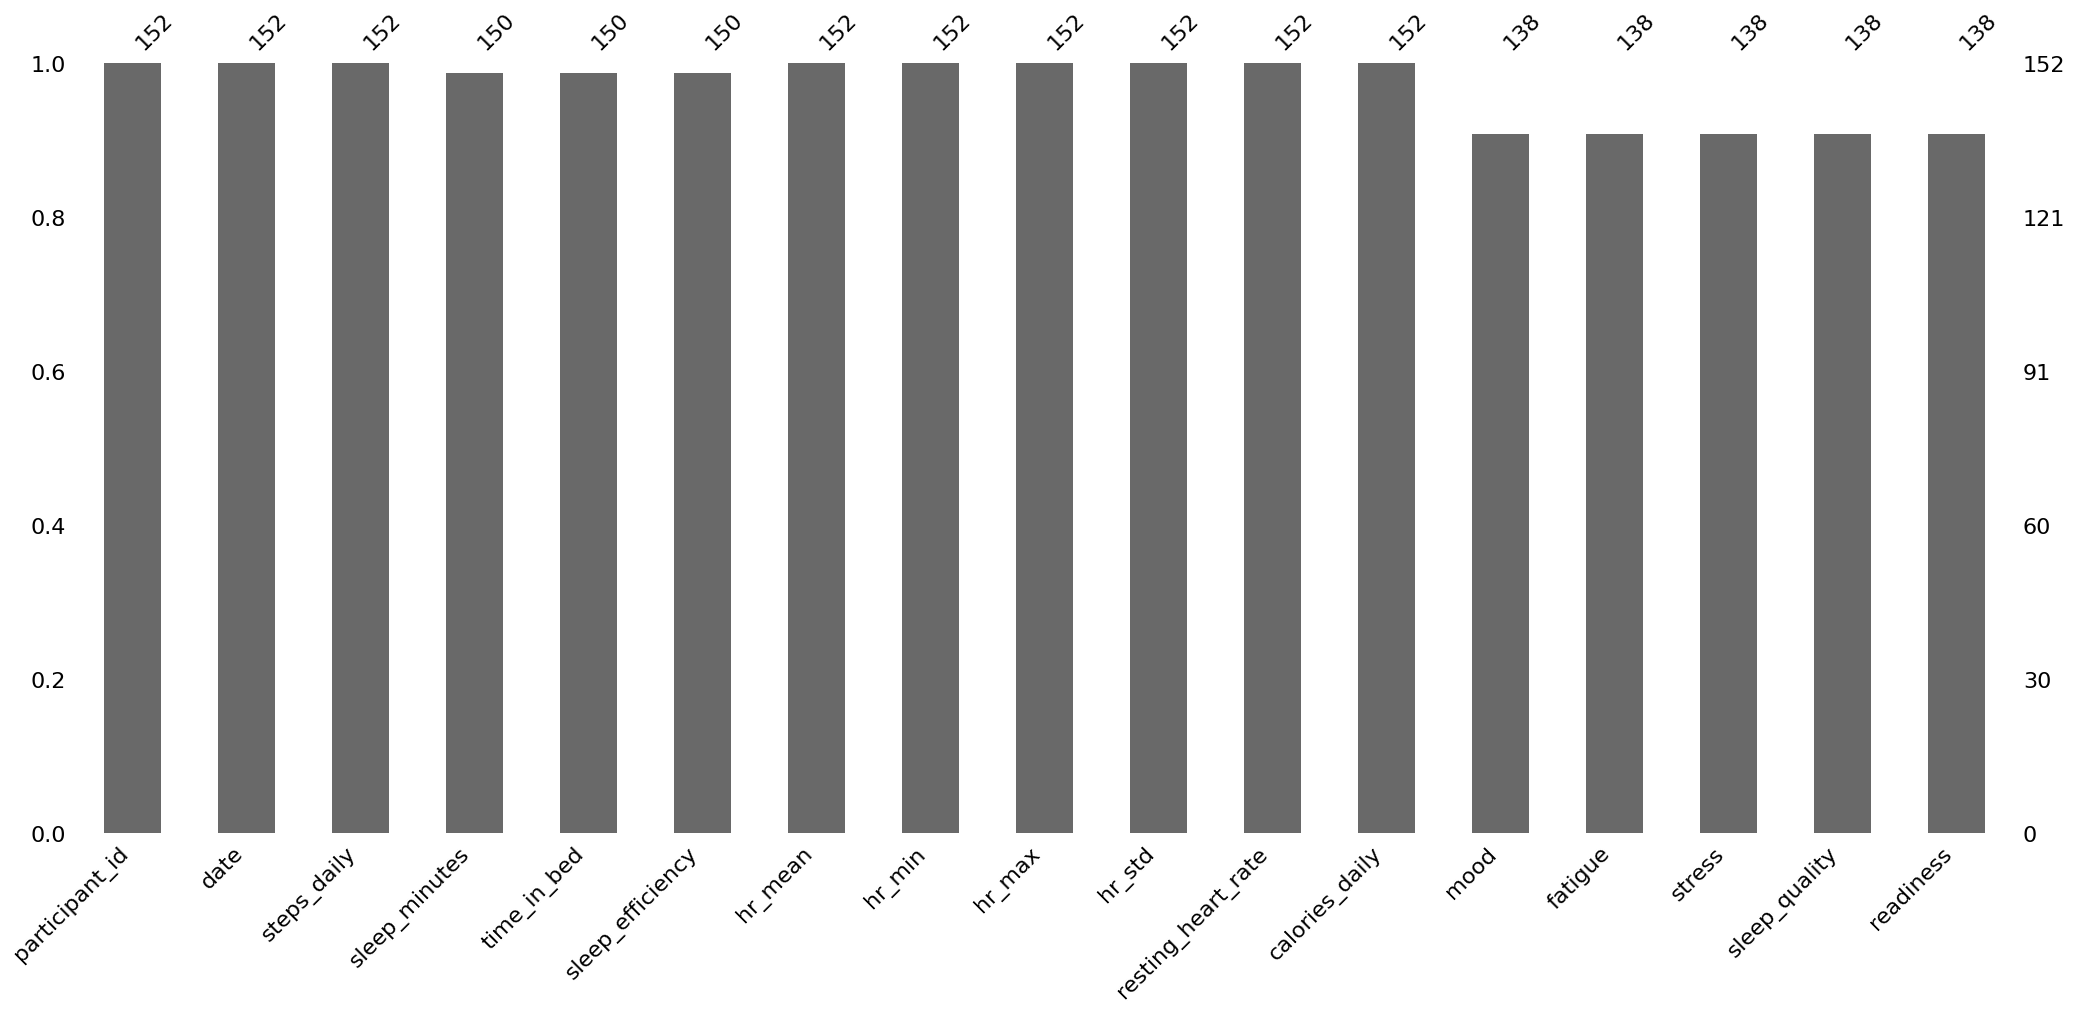

In [68]:
msno.bar(p01_df)

<Axes: >

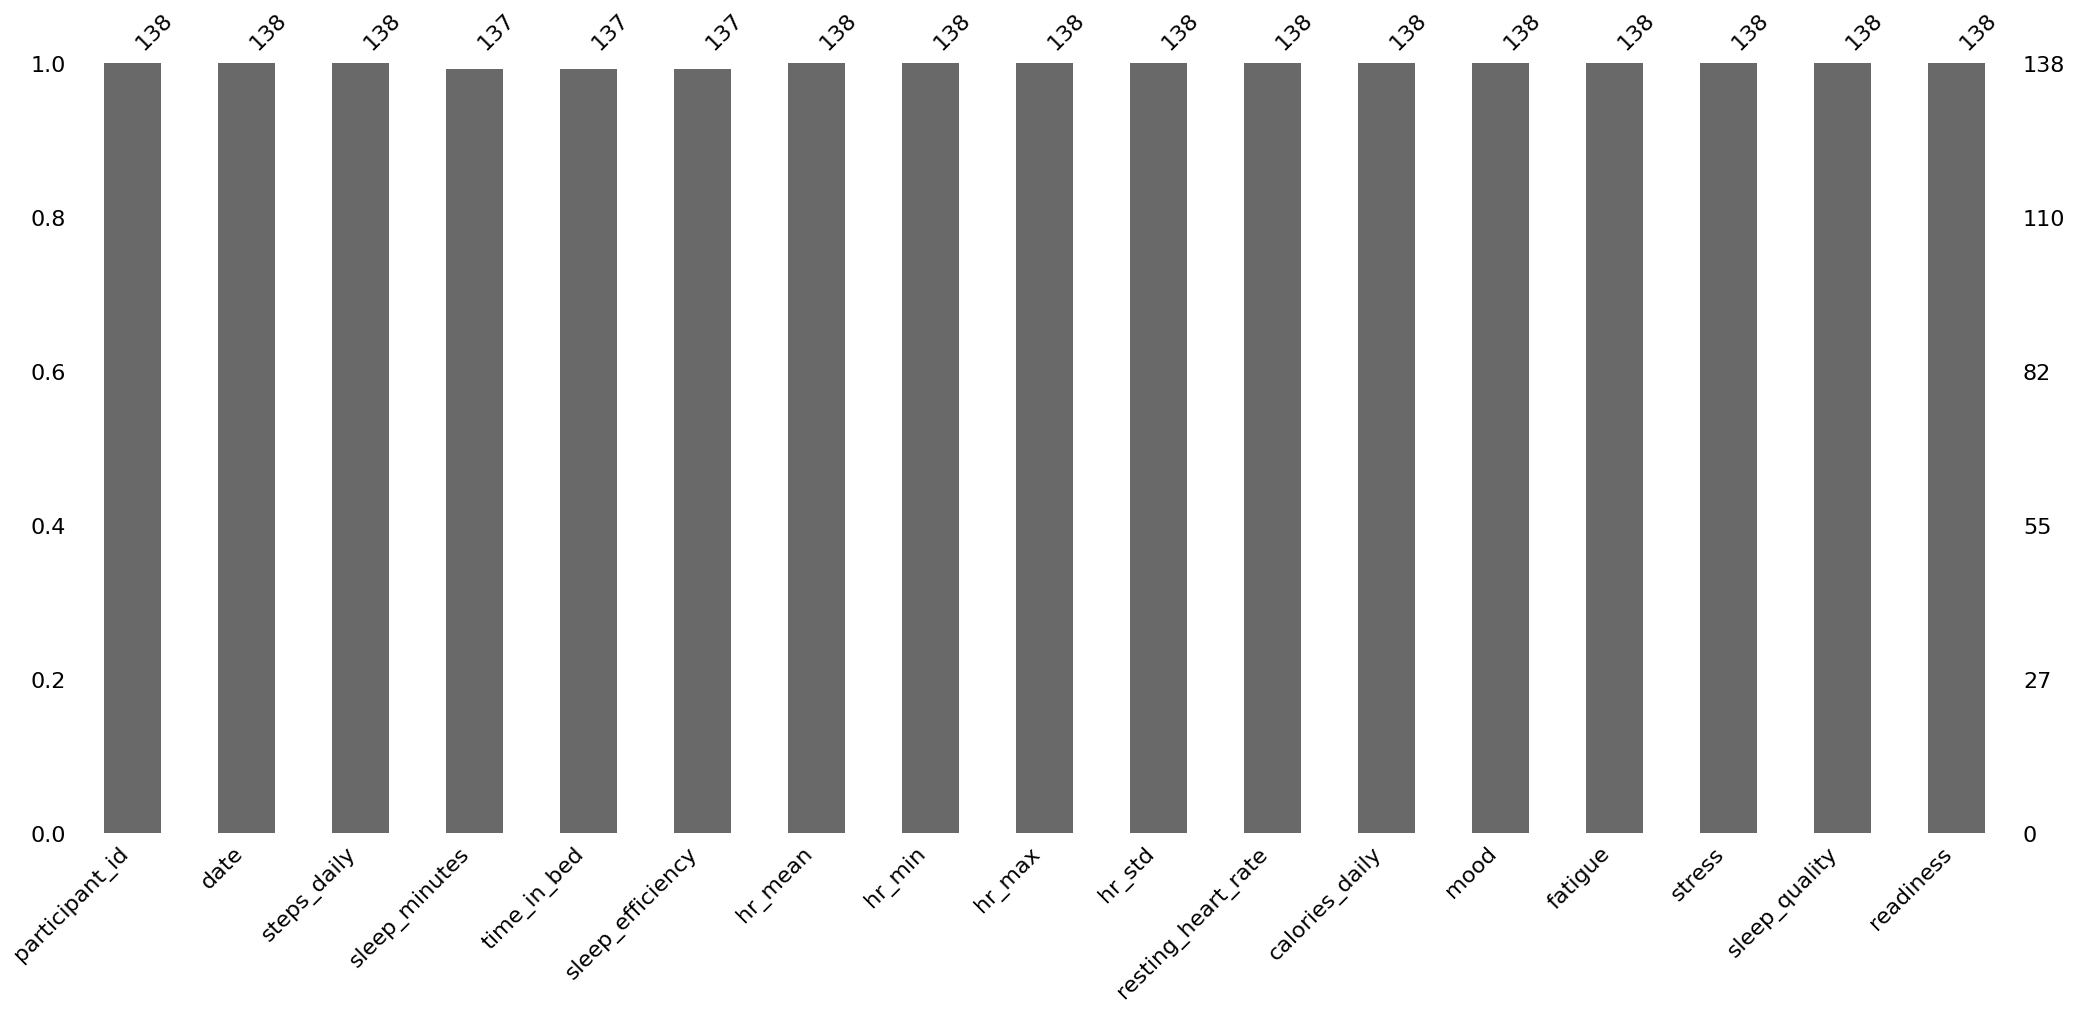

In [70]:
target = "readiness"

model_df = p01_df.dropna(subset=[target])
msno.bar(model_df)

In [72]:
feature_cols = [
    "steps_daily",
    "sleep_minutes",
    "time_in_bed",
    "sleep_efficiency",
    "hr_mean",
    "hr_min",
    "hr_max",
    "hr_std",
    "resting_heart_rate",
    "calories_daily",
    "mood",
]
model_df[feature_cols + [target]].isna().sum()



steps_daily           0
sleep_minutes         1
time_in_bed           1
sleep_efficiency      1
hr_mean               0
hr_min                0
hr_max                0
hr_std                0
resting_heart_rate    0
calories_daily        0
mood                  0
readiness             0
dtype: int64

#### Create featurs for all participants

In [78]:
from tqdm import tqdm
participant_ids = sorted(
    p.name for p in tqdm(RAW_DATA_DIR.iterdir())
    if p.is_dir() and p.name.startswith("p")
)

participant_ids

18it [00:00, 71765.66it/s]


['p01',
 'p02',
 'p03',
 'p04',
 'p05',
 'p06',
 'p07',
 'p08',
 'p09',
 'p10',
 'p11',
 'p12',
 'p13',
 'p14',
 'p15',
 'p16']

In [79]:
all_features_df = pd.concat(
    [aggregate_participant_features(pid) for pid in tqdm(participant_ids)],
    ignore_index=True
)

100%|██████████| 16/16 [01:20<00:00,  5.01s/it]


In [80]:
all_features_df.shape
all_features_df.head()
all_features_df["participant_id"].value_counts()
all_features_df.isna().sum().sort_values(ascending=False)

fatigue               669
mood                  669
stress                669
sleep_quality         669
readiness             669
resting_heart_rate    595
sleep_efficiency      517
time_in_bed           517
sleep_minutes         517
hr_std                218
hr_max                217
hr_mean               217
hr_min                217
steps_daily           101
calories_daily         52
participant_id          0
date                    0
dtype: int64

In [81]:
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

all_features_df.to_parquet(
    PROCESSED_DATA_DIR / "pmdata_daily_features.parquet",
    index=False
)
all_features_df.to_csv(
    PROCESSED_DATA_DIR / "pmdata_daily_features.csv",
    index=False
)